In [1]:
# 1. Clone repo
!git clone https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch.git

# 2. DI CHUYỂN vào thư mục repo (BƯỚC QUAN TRỌNG NHẤT)
# Dùng %cd để thay đổi thư mục làm việc của notebook
%cd Yet-Another-EfficientDet-Pytorch

c:\Study\code\dsp391_assignment\Yet-Another-EfficientDet-Pytorch


Cloning into 'Yet-Another-EfficientDet-Pytorch'...
c:\Study\code\dsp391_assignment\venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!pip install pycocotools numpy==1.16.0 opencv-python tqdm tensorboard tensorboardX pyyaml webcolors matplotlib


  Using cached pycocotools-2.0.10-cp310-cp310-win_amd64.whl (80 kB)
     ---------------------------------------- 5.1/5.1 MB 74.9 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
     --------------------------------------- 87.2/87.2 kB 50.3 kB/s eta 0:00:00
  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
     -                                        1.3/38.8 MB 84.2 kB/s eta 0:07:27


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Study\code\dsp391_assignment\venv\lib\site-packages\pip\_vendor\urllib3\response.py", line 437, in _error_catcher
    yield
  File "C:\Study\code\dsp391_assignment\venv\lib\site-packages\pip\_vendor\urllib3\response.py", line 560, in read
    data = self._fp_read(amt) if not fp_closed else b""
  File "C:\Study\code\dsp391_assignment\venv\lib\site-packages\pip\_vendor\urllib3\response.py", line 526, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "C:\Study\code\dsp391_assignment\venv\lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 90, in read
    data = self.__fp.read(amt)
  File "C:\Users\fa170\AppData\Local\Programs\Python\Python310\lib\http\client.py", line 465, in read
    s = self.fp.read(amt)
  File "C:\Users\fa170\AppData\Local\Programs\Python\Python310\lib\socket.py", line 705, in readinto
    return self._sock.recv_into(b)
  File "C:\Users\fa170\AppData\Loca

In [31]:
# 4. Tạo thư mục 'weights' (BÊN TRONG repo) và tải weights
! mkdir weights
! wget https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d1.pth -O weights/efficientdet-d1.pth

mkdir: cannot create directory ‘weights’: File exists
--2025-11-11 14:03:19--  https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d1.pth
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/253385242/44e41700-791e-11ea-94c5-3d69afce13e8?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-11T14%3A57%3A07Z&rscd=attachment%3B+filename%3Defficientdet-d1.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-11T13%3A56%3A58Z&ske=2025-11-11T14%3A57%3A07Z&sks=b&skv=2018-11-09&sig=6Bg606uctGwtO69UhBrH9Rd4lfHZ7jCuXvl%2FTL63nlY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cC

In [30]:
# Xóa file .pth bị lỗi
#!rm /kaggle/working/Yet-Another-EfficientDet-Pytorch/weights/efficientdet-d1.pth

In [4]:
# XÓA SYMLINK CŨ
#!rm -rf weights/efficientdet-d0.pth

In [5]:
# Tạo cấu trúc thư mục MÀ REPO MONG MUỐN
# -p sẽ tạo 'datasets/acne' và 'datasets/acne/annotations' cùng lúc
!mkdir -p datasets/acne/annotations

# Link thư mục 'train' (chứa ảnh)
!ln -s "/kaggle/input/acnedet/ACNEDet v1.v2i.coco/train" ./datasets/acne/train

# Link thư mục 'valid' (chứa ảnh)
!ln -s "/kaggle/input/acnedet/ACNEDet v1.v2i.coco/valid" ./datasets/acne/valid

# Link file annotation của TẬP TRAIN
!ln -s "/kaggle/input/acnedet/ACNEDet v1.v2i.coco/train/_annotations.coco.json" ./datasets/acne/annotations/instances_train.json

# Link file annotation của TẬP VALID
!ln -s "/kaggle/input/acnedet/ACNEDet v1.v2i.coco/valid/_annotations.coco.json" ./datasets/acne/annotations/instances_valid.json

# 6. (Kiểm tra) Xem symlink đã đúng chưa
!ls -l datasets/acne/
!ls -l datasets/acne/annotations/

total 4
drwxr-xr-x 2 root root 4096 Nov 11 13:42 annotations
lrwxrwxrwx 1 root root   47 Nov 11 13:42 train -> '/kaggle/input/acnedet/ACNEDet v1.v2i.coco/train'
lrwxrwxrwx 1 root root   47 Nov 11 13:42 valid -> '/kaggle/input/acnedet/ACNEDet v1.v2i.coco/valid'
total 8
lrwxrwxrwx 1 root root 70 Nov 11 13:42 instances_train.json -> '/kaggle/input/acnedet/ACNEDet v1.v2i.coco/train/_annotations.coco.json'
lrwxrwxrwx 1 root root 70 Nov 11 13:42 instances_valid.json -> '/kaggle/input/acnedet/ACNEDet v1.v2i.coco/valid/_annotations.coco.json'


In [6]:
!pip install wandb

In [12]:
import wandb
from kaggle_secrets import UserSecretsClient

# Lấy key từ Kaggle Secrets
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("wandb_key")

# Đăng nhập
wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: thuanhhse180160 (thuanhhse180160-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
%%writefile projects/acne.yml
# Tên project (phải khớp với tên symlink 'acne')
project_name: acne

# Tên thư mục train/val (phải khớp với tên bên trong data của bạn)
# LƯU Ý: Hãy kiểm tra lại data của bạn xem có đúng là 'train_images' và 'val_images' không
# Data từ Roboflow v2i.coco thường là 'train' và 'valid'
train_set: train
val_set: valid

# Số GPU (trên Kaggle thường là 1)
num_gpus: 1

# Các thông số còn lại giữ nguyên
mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
anchors_scales: '[2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)]'
anchors_ratios: '[(1.0, 1.0), (1.4, 0.7), (0.7, 1.4)]'

# Danh sách lớp (phải khớp với file .json)
obj_list: ['comedone', 'pustules', 'nodules', 'papules']

Writing projects/acne.yml


In [14]:
# Đảm bảo bạn đang ở đúng thư mục /kaggle/working/
# Lệnh này sẽ in toàn bộ code của file train.py ra output
!cat /kaggle/working/Yet-Another-EfficientDet-Pytorch/train.py

# original author: signatrix
# adapted from https://github.com/signatrix/efficientdet/blob/master/train.py
# modified by Zylo117

import argparse
import datetime
import os
import traceback

import numpy as np
import torch
import yaml
from tensorboardX import SummaryWriter
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.autonotebook import tqdm

from backbone import EfficientDetBackbone
from efficientdet.dataset import CocoDataset, Resizer, Normalizer, Augmenter, collater
from efficientdet.loss import FocalLoss
from utils.sync_batchnorm import patch_replication_callback
from utils.utils import replace_w_sync_bn, CustomDataParallel, get_last_weights, init_weights, boolean_string


class Params:
    def __init__(self, project_file):
        self.params = yaml.safe_load(open(project_file).read())

    def __getattr__(self, item):
        return self.params.get(item, None)


def get_args():
    parser = argparse.ArgumentParser('Yet A

In [28]:
%%writefile /kaggle/working/Yet-Another-EfficientDet-Pytorch/train.py
# original author: signatrix
# adapted from https://github.com/signatrix/efficientdet/blob/master/train.py
# modified by Zylo117

import argparse
import datetime
import os
import traceback

import numpy as np
import torch
import yaml
from tensorboardX import SummaryWriter
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.autonotebook import tqdm

from backbone import EfficientDetBackbone
from efficientdet.dataset import CocoDataset, Resizer, Normalizer, Augmenter, collater
from efficientdet.loss import FocalLoss
from utils.sync_batchnorm import patch_replication_callback
from utils.utils import replace_w_sync_bn, CustomDataParallel, get_last_weights, init_weights, boolean_string
import wandb 

class Params:
    def __init__(self, project_file):
        self.params = yaml.safe_load(open(project_file).read())

    def __getattr__(self, item):
        return self.params.get(item, None)


def get_args():
    parser = argparse.ArgumentParser('Yet Another EfficientDet Pytorch: SOTA object detection network - Zylo117')
    parser.add_argument('-p', '--project', type=str, default='coco', help='project file that contains parameters')
    parser.add_argument('-c', '--compound_coef', type=int, default=0, help='coefficients of efficientdet')
    parser.add_argument('-n', '--num_workers', type=int, default=12, help='num_workers of dataloader')
    parser.add_argument('--batch_size', type=int, default=12, help='The number of images per batch among all devices')
    parser.add_argument('--head_only', type=boolean_string, default=False,
                        help='whether finetunes only the regressor and the classifier, '
                             'useful in early stage convergence or small/easy dataset')
    parser.add_argument('--lr', type=float, default=1e-4)
    parser.add_argument('--optim', type=str, default='adamw', help='select optimizer for training, '
                                                                   'suggest using \'admaw\' until the'
                                                                   ' very final stage then switch to \'sgd\'')
    parser.add_argument('--num_epochs', type=int, default=500)
    parser.add_argument('--val_interval', type=int, default=1, help='Number of epoches between valing phases')
    parser.add_argument('--save_interval', type=int, default=500, help='Number of steps between saving')
    parser.add_argument('--es_min_delta', type=float, default=0.0,
                        help='Early stopping\'s parameter: minimum change loss to qualify as an improvement')
    parser.add_argument('--es_patience', type=int, default=0,
                        help='Early stopping\'s parameter: number of epochs with no improvement after which training will be stopped. Set to 0 to disable this technique.')
    parser.add_argument('--data_path', type=str, default='datasets/', help='the root folder of dataset')
    parser.add_argument('--log_path', type=str, default='logs/')
    parser.add_argument('-w', '--load_weights', type=str, default=None,
                        help='whether to load weights from a checkpoint, set None to initialize, set \'last\' to load last checkpoint')
    parser.add_argument('--saved_path', type=str, default='logs/')
    parser.add_argument('--debug', type=boolean_string, default=False,
                        help='whether visualize the predicted boxes of training, '
                             'the output images will be in test/')

    args = parser.parse_args()
    return args


class ModelWithLoss(nn.Module):
    def __init__(self, model, debug=False):
        super().__init__()
        self.criterion = FocalLoss()
        self.model = model
        self.debug = debug

    def forward(self, imgs, annotations, obj_list=None):
        _, regression, classification, anchors = self.model(imgs)
        if self.debug:
            cls_loss, reg_loss = self.criterion(classification, regression, anchors, annotations,
                                                imgs=imgs, obj_list=obj_list)
        else:
            cls_loss, reg_loss = self.criterion(classification, regression, anchors, annotations)
        return cls_loss, reg_loss


def train(opt):
    params = Params(f'projects/{opt.project}.yml')
    # --- THÊM KHỐI CODE NÀY ---
    wandb.init(
        project="acne-detection_test",  # Đặt tên project của bạn
        
        # Ghi lại các siêu tham số (hyperparameters)
        config={
            "learning_rate": opt.lr,
            "batch_size": opt.batch_size,
            "epochs": opt.num_epochs,
            "model": f"efficientdet-d{opt.compound_coef}",  # <-- SỬA LẠI NHƯ THẾ NÀY 
            "head_only": opt.head_only,
        }
    )
    #------------ END -------------
    if params.num_gpus == 0:
        os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)
    else:
        torch.manual_seed(42)

    opt.saved_path = opt.saved_path + f'/{params.project_name}/'
    opt.log_path = opt.log_path + f'/{params.project_name}/tensorboard/'
    os.makedirs(opt.log_path, exist_ok=True)
    os.makedirs(opt.saved_path, exist_ok=True)

    training_params = {'batch_size': opt.batch_size,
                       'shuffle': True,
                       'drop_last': True,
                       'collate_fn': collater,
                       'num_workers': opt.num_workers}

    val_params = {'batch_size': opt.batch_size,
                  'shuffle': False,
                  'drop_last': True,
                  'collate_fn': collater,
                  'num_workers': opt.num_workers}

    input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536]
    training_set = CocoDataset(root_dir=os.path.join(opt.data_path, params.project_name), set=params.train_set,
                               transform=transforms.Compose([Normalizer(mean=params.mean, std=params.std),
                                                             Augmenter(),
                                                             Resizer(input_sizes[opt.compound_coef])]))
    training_generator = DataLoader(training_set, **training_params)

    val_set = CocoDataset(root_dir=os.path.join(opt.data_path, params.project_name), set=params.val_set,
                          transform=transforms.Compose([Normalizer(mean=params.mean, std=params.std),
                                                        Resizer(input_sizes[opt.compound_coef])]))
    val_generator = DataLoader(val_set, **val_params)

    model = EfficientDetBackbone(num_classes=len(params.obj_list), compound_coef=opt.compound_coef,
                                 ratios=eval(params.anchors_ratios), scales=eval(params.anchors_scales))

    # load last weights
    if opt.load_weights is not None:
        if opt.load_weights.endswith('.pth'):
            weights_path = opt.load_weights
        else:
            weights_path = get_last_weights(opt.saved_path)
        try:
            last_step = int(os.path.basename(weights_path).split('_')[-1].split('.')[0])
        except:
            last_step = 0

        try:
            ret = model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=False), strict=False)        
        except RuntimeError as e:
            print(f'[Warning] Ignoring {e}')
            print(
                '[Warning] Don\'t panic if you see this, this might be because you load a pretrained weights with different number of classes. The rest of the weights should be loaded already.')

        print(f'[Info] loaded weights: {os.path.basename(weights_path)}, resuming checkpoint from step: {last_step}')
    else:
        last_step = 0
        print('[Info] initializing weights...')
        init_weights(model)

    # freeze backbone if train head_only
    if opt.head_only:
        def freeze_backbone(m):
            classname = m.__class__.__name__
            for ntl in ['EfficientNet', 'BiFPN']:
                if ntl in classname:
                    for param in m.parameters():
                        param.requires_grad = False

        model.apply(freeze_backbone)
        print('[Info] freezed backbone')

    # https://github.com/vacancy/Synchronized-BatchNorm-PyTorch
    # apply sync_bn when using multiple gpu and batch_size per gpu is lower than 4
    #  useful when gpu memory is limited.
    # because when bn is disable, the training will be very unstable or slow to converge,
    # apply sync_bn can solve it,
    # by packing all mini-batch across all gpus as one batch and normalize, then send it back to all gpus.
    # but it would also slow down the training by a little bit.
    if params.num_gpus > 1 and opt.batch_size // params.num_gpus < 4:
        model.apply(replace_w_sync_bn)
        use_sync_bn = True
    else:
        use_sync_bn = False

    writer = SummaryWriter(opt.log_path + f'/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}/')

    # warp the model with loss function, to reduce the memory usage on gpu0 and speedup
    model = ModelWithLoss(model, debug=opt.debug)

    if params.num_gpus > 0:
        model = model.cuda()
        if params.num_gpus > 1:
            model = CustomDataParallel(model, params.num_gpus)
            if use_sync_bn:
                patch_replication_callback(model)

    if opt.optim == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), opt.lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), opt.lr, momentum=0.9, nesterov=True)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)

    epoch = 0
    best_loss = 1e5
    best_epoch = 0
    step = max(0, last_step)
    model.train()

    num_iter_per_epoch = len(training_generator)

    try:
        for epoch in range(opt.num_epochs):
            last_epoch = step // num_iter_per_epoch
            if epoch < last_epoch:
                continue

            epoch_loss = []
            progress_bar = tqdm(training_generator)
            for iter, data in enumerate(progress_bar):
                if iter < step - last_epoch * num_iter_per_epoch:
                    progress_bar.update()
                    continue
                try:
                    imgs = data['img']
                    annot = data['annot']

                    if params.num_gpus == 1:
                        # if only one gpu, just send it to cuda:0
                        # elif multiple gpus, send it to multiple gpus in CustomDataParallel, not here
                        imgs = imgs.cuda()
                        annot = annot.cuda()

                    optimizer.zero_grad()
                    cls_loss, reg_loss = model(imgs, annot, obj_list=params.obj_list)
                    cls_loss = cls_loss.mean()
                    reg_loss = reg_loss.mean()

                    loss = cls_loss + reg_loss
                    if loss == 0 or not torch.isfinite(loss):
                        continue

                    loss.backward()
                    # torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
                    optimizer.step()

                    epoch_loss.append(float(loss))

                    progress_bar.set_description(
                        'Step: {}. Epoch: {}/{}. Iteration: {}/{}. Cls loss: {:.5f}. Reg loss: {:.5f}. Total loss: {:.5f}'.format(
                            step, epoch, opt.num_epochs, iter + 1, num_iter_per_epoch, cls_loss.item(),
                            reg_loss.item(), loss.item()))
                    writer.add_scalars('Loss', {'train': loss}, step)
                    writer.add_scalars('Regression_loss', {'train': reg_loss}, step)
                    writer.add_scalars('Classfication_loss', {'train': cls_loss}, step)

                    # log learning_rate
                    current_lr = optimizer.param_groups[0]['lr']
                    writer.add_scalar('learning_rate', current_lr, step)
                    
                    # --- THÊM KHỐI CODE NÀY VÀO ---
                    wandb.log({
                          "train_total_loss": loss.item(),
                          "train_reg_loss": reg_loss.item(),
                          "train_cls_loss": cls_loss.item(),
                          "learning_rate": current_lr,
                          "step": step,
                          "epoch": epoch
                      })
                      # --- KẾT THÚC KHỐI CODE THÊM ---

                    step += 1

                    if step % opt.save_interval == 0 and step > 0:
                        save_checkpoint(model, f'efficientdet-d{opt.compound_coef}_{epoch}_{step}.pth')
                        print('checkpoint...')

                except Exception as e:
                    print('[Error]', traceback.format_exc())
                    print(e)
                    continue
            scheduler.step(np.mean(epoch_loss))

            if epoch % opt.val_interval == 0:
                model.eval()
                loss_regression_ls = []
                loss_classification_ls = []
                for iter, data in enumerate(val_generator):
                    with torch.no_grad():
                        imgs = data['img']
                        annot = data['annot']

                        if params.num_gpus == 1:
                            imgs = imgs.cuda()
                            annot = annot.cuda()

                        cls_loss, reg_loss = model(imgs, annot, obj_list=params.obj_list)
                        cls_loss = cls_loss.mean()
                        reg_loss = reg_loss.mean()

                        loss = cls_loss + reg_loss
                        if loss == 0 or not torch.isfinite(loss):
                            continue

                        loss_classification_ls.append(cls_loss.item())
                        loss_regression_ls.append(reg_loss.item())

                cls_loss = np.mean(loss_classification_ls)
                reg_loss = np.mean(loss_regression_ls)
                loss = cls_loss + reg_loss

                print(
                    'Val. Epoch: {}/{}. Classification loss: {:1.5f}. Regression loss: {:1.5f}. Total loss: {:1.5f}'.format(
                        epoch, opt.num_epochs, cls_loss, reg_loss, loss))
                writer.add_scalars('Loss', {'val': loss}, step)
                writer.add_scalars('Regression_loss', {'val': reg_loss}, step)
                writer.add_scalars('Classfication_loss', {'val': cls_loss}, step)

                # --- THÊM KHỐI CODE NÀY VÀO ---
                wandb.log({
                          "val_total_loss": loss,
                          "val_reg_loss": reg_loss,
                          "val_cls_loss": cls_loss,
                          "step": step,
                          "epoch": epoch
                })
                      # --- KẾT THÚC KHỐI CODE THÊM ---

                if loss + opt.es_min_delta < best_loss:
                    best_loss = loss
                    best_epoch = epoch

                    save_checkpoint(model, f'efficientdet-d{opt.compound_coef}_{epoch}_{step}.pth')

                model.train()

                # Early stopping
                if epoch - best_epoch > opt.es_patience > 0:
                    print('[Info] Stop training at epoch {}. The lowest loss achieved is {}'.format(epoch, best_loss))
                    break
                    wandb.finish()  # <-- THÊM VÀO ĐÂY
    except KeyboardInterrupt:
        save_checkpoint(model, f'efficientdet-d{opt.compound_coef}_{epoch}_{step}.pth')
        writer.close()
        wandb.finish()  # <-- THÊM VÀO ĐÂY
    writer.close()
    wandb.finish()  # <-- THÊM VÀO ĐÂY


def save_checkpoint(model, name):
    if isinstance(model, CustomDataParallel):
        torch.save(model.module.model.state_dict(), os.path.join(opt.saved_path, name))
    else:
        torch.save(model.model.state_dict(), os.path.join(opt.saved_path, name))


if __name__ == '__main__':
    opt = get_args()
    train(opt)

Overwriting /kaggle/working/Yet-Another-EfficientDet-Pytorch/train.py


In [21]:
!pip install tensorboardX

  Using cached tensorboardx-2.6.4-py3-none-any.whl.metadata (6.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.8 MB/s eta 0:00:00


In [32]:
# 8. Chạy training (Bây giờ sẽ tìm thấy train.py)
# TRAIN VỚI 'head_only'
!python train.py -c 1 -p acne --head_only True --lr 2e-4 --batch_size 16 --load_weights /kaggle/working/Yet-Another-EfficientDet-Pytorch/weights/efficientdet-d1.pth  --num_epochs 10 --save_interval 100

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [34]:
# TÍNH ĐIỂM mAP
# Sửa 'efficientdet-d0_9.pth' thành tên file .pth cuối cùng của bạn
# Đánh giá file checkpoint cuối cùng của Epoch 0
!python coco_eval.py -c 1 -p acne -w /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_9_2470.pth

running coco-style evaluation on project acne, weights /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_9_2470.pth...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
100%|█████████████████████████████████████████| 320/320 [00:40<00:00,  7.95it/s]
Loading and preparing results...
DONE (t=24.65s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=12.04s).
Accumulating evaluation results...
DONE (t=0.71s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] =

In [ ]:
# TEST TRÊN ẢNH

# Lệnh này sẽ tìm 'np.int' trong file và thay thế bằng 'int'
!sed -i 's/np\.int/int/g' efficientdet_test.py

# Sửa 'efficientdet-d0_9.pth' thành tên file .pth của bạn
!python efficientdet_test.py -c 0 -p acne -w logs/acne/efficientdet-d0_0_247.pth \

# Sửa '/path/to/test_image.jpg' thành đường dẫn đến ảnh bạn muốn thử
--input /kaggle/input/acnedet/ACNEDet\ v1.v2i.coco/valid/acne-1_jpg.rf.0a1b2c...jpg \
--output /kaggle/working/output_image.jpg --show

In [36]:
# FINETUNE TOÀN BỘ 
!python train.py -c 1 -p acne \
--head_only False \
--lr 1e-5 \
--batch_size 8 \
--load_weights /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_9_2470.pth \
--num_epochs 20 \
--save_interval 200

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [37]:
# TÍNH ĐIỂM mAP
# Sửa 'efficientdet-d0_9.pth' thành tên file .pth cuối cùng của bạn
# Đánh giá file checkpoint cuối cùng của Epoch 0
!python coco_eval.py -c 1 -p acne -w /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_19_9900.pth

running coco-style evaluation on project acne, weights /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_19_9900.pth...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
100%|█████████████████████████████████████████| 320/320 [00:21<00:00, 15.12it/s]
Loading and preparing results...
DONE (t=0.74s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.27s).
Accumulating evaluation results...
DONE (t=0.26s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.078
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.195
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.049
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.073
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.091
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 

In [43]:
# Thêm 'import sys' vào dòng 1
!sed -i '1s/^/import sys\n/' efficientdet_test.py

In [49]:
# Lệnh này tìm lại hack cũ của chúng ta và thay thế nó bằng hack mới đã có strict=False
#!sed -i "s|torch.load(sys.argv\[sys.argv.index('-w') + 1\], map_location='cpu')|torch.load(sys.argv[sys.argv.index('-w') + 1], map_location='cpu'), strict=False|g" efficientdet_test.py
# TEST TRÊN ẢNH

# Cell 1: Vá lỗi file test (3 lệnh)

# 1. Vá lỗi numpy
!sed -i 's/np\.int/int/g' efficientdet_test.py

# 2. Vá lỗi hard-coded D0 -> D1 (bạn đã làm)
!sed -i 's/compound_coef = 0/compound_coef = 1/g' efficientdet_test.py

# 3. VÁ LỖI QUAN TRỌNG NHẤT: Sửa 90 class -> 4 class
# Lệnh này tìm 'num_classes=len(obj_list)' (dòng 59) và thay bằng 'num_classes=4'
!sed -i 's/num_classes=len(obj_list)/num_classes=4/g' efficientdet_test.py

# Sửa 'efficientdet-d0_9.pth' thành tên file .pth của bạn
!python efficientdet_test.py -c 1 -p acne -w /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_19_9900.pth \--input /kaggle/working/Yet-Another-EfficientDet-Pytorch/datasets/acne/valid/01F3MMVMD3Q7GAY0YKSMEZ76K5_jpeg_jpg.rf.adceb2f987aa735d7c46d6c7706073a4.jpg \--output /kaggle/working/output_image.jpg --show


running speed test...
test1: model inferring and postprocessing
inferring image for 10 times...
0.049335575103759764 seconds, 20.269349204845735 FPS, @batch_size 1


In [55]:
# Cell 1: Vá lỗi file test (3 lệnh)
!sed -i 's/np\.int/int/g' efficientdet_test.py

!sed -i 's/compound_coef = 0/compound_coef = 1/g' efficientdet_test.py
!sed -i 's/num_classes=len(obj_list)/num_classes=4/g' efficientdet_test.py

# Cell 2: Chạy test (ĐÃ XÓA TẤT CẢ CÁC DẤU '\' VÀ GOM VỀ MỘT DÒNG)
!python efficientdet_test.py -c 1 -p acne -w /kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_19_9900.pth --input /kaggle/working/Yet-Another-EfficientDet-Pytorch/datasets/acne/valid/01F3MMVMD3Q7GAY0YKSMEZ76K5_jpeg_jpg.rf.adceb2f987aa735d7c46d6c7706073a4.jpg --output /kaggle/working/output_image.jpg --show

running speed test...
test1: model inferring and postprocessing
inferring image for 10 times...
0.048844194412231444 seconds, 20.473262217414778 FPS, @batch_size 1


Đang tải cấu hình và dữ liệu...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Đang tải mô hình...
Đang chạy inference và so khớp (IoU threshold=0.2)...


100%|██████████| 80/80 [00:08<00:00,  9.41it/s]


Đang tạo ma trận nhầm lẫn...


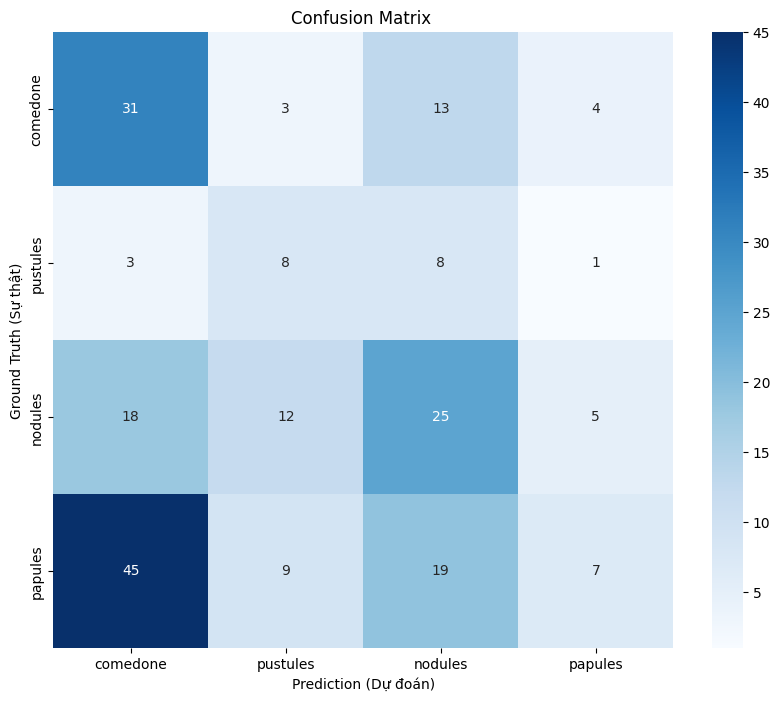


--- Phân tích Ma trận ---
Ma trận này chỉ tính các vật thể mà mô hình TÌM THẤY (IoU > 0.2).
Nó KHÔNG tính các trường hợp BỎ LỠ (False Negatives) hoặc DỰ ĐOÁN SAI (False Positives).
Ô (i, i) (đường chéo): Số lần dự đoán đúng class.


NameError: name 'j' is not defined

In [70]:
import torch
import numpy as np
import os
import yaml
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# 1. HÀM TÍNH IoU (Intersection over Union)
# ---------------------------------------------------------------
def jaccard_numpy(box_a, box_b):
    """
    Tính IoU (Jaccard Overlap) giữa hai tập hợp bounding box.
    """
    if box_a.shape[0] == 0 or box_b.shape[0] == 0:
        return np.zeros((box_a.shape[0], box_b.shape[0]))
        
    # Xác định tọa độ (x1, y1, x2, y2) của vùng giao nhau (intersection)
    xA = np.maximum(box_a[:, 0, None], box_b[None, :, 0])
    yA = np.maximum(box_a[:, 1, None], box_b[None, :, 1])
    xB = np.minimum(box_a[:, 2, None], box_b[None, :, 2])
    yB = np.minimum(box_a[:, 3, None], box_b[None, :, 3])

    # Tính diện tích vùng giao nhau
    interArea = np.maximum(0, xB - xA) * np.maximum(0, yB - yA)

    # Tính diện tích của mỗi hộp
    boxAArea = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])
    boxBArea = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])
    
    # Tính diện tích vùng hợp nhau (union)
    unionArea = (boxAArea[:, None] + boxBArea[None, :] - interArea)
    
    # Tính IoU
    iou = interArea / unionArea
    # Xử lý trường hợp chia cho 0 (nếu unionArea = 0)
    iou[np.isnan(iou)] = 0
    return iou

# ---------------------------------------------------------------
# 2. HÀM POSTPROCESS (ĐÃ SỬA LỖI INDEXERROR)
# ---------------------------------------------------------------
def clip_boxes(boxes, img_shape):
    """
    Clip boxes to image boundaries.
    """
    height, width = img_shape
    # Đảm bảo boxes là numpy array
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.cpu().numpy()
        
    x1 = np.maximum(0, np.minimum(boxes[:, 0], width))
    y1 = np.maximum(0, np.minimum(boxes[:, 1], height))
    x2 = np.maximum(0, np.minimum(boxes[:, 2], width))
    y2 = np.maximum(0, np.minimum(boxes[:, 3], height))
    return np.stack([x1, y1, x2, y2], axis=1)

def postprocess(imgs, anchors, regression, classification, score_threshold, iou_threshold):
    """
    Hàm Postprocess (ĐÃ SỬA LỖI INDEXERROR)
    """
    if torch.cuda.is_available():
        anchors = anchors.cuda()

    batch_size = regression.shape[0]
    batch_outputs = []

    for i in range(batch_size):
        reg = regression[i]       # Shape [num_anchors, 4]
        cls = classification[i]   # Shape [num_anchors, num_classes]
        img_shape = imgs[i].shape[1:]  # (height, width)
        
        # --- SỬA LỖI Ở ĐÂY (DÒNG 78) ---
        # Anchors không được batch (hoặc batch_size=1). 
        # Chúng ta dùng anchors[0] cho TẤT CẢ các ảnh.
        current_anchors = anchors[0]  # Shape [num_anchors, 4]

        # 1. Giải mã Bounding Boxes (Dùng current_anchors)
        anchors_w = current_anchors[:, 2] - current_anchors[:, 0]
        anchors_h = current_anchors[:, 3] - current_anchors[:, 1]
        anchors_x_ctr = current_anchors[:, 0] + 0.5 * anchors_w
        anchors_y_ctr = current_anchors[:, 1] + 0.5 * anchors_h

        dx, dy, dw, dh = reg.chunk(4, dim=1)
        dx = dx.squeeze(1)
        dy = dy.squeeze(1)
        dw = dw.squeeze(1)
        dh = dh.squeeze(1)

        pred_x_ctr = dx * anchors_w + anchors_x_ctr
        pred_y_ctr = dy * anchors_h + anchors_y_ctr
        pred_w = torch.exp(dw) * anchors_w
        pred_h = torch.exp(dh) * anchors_h

        pred_x1 = pred_x_ctr - 0.5 * pred_w
        pred_y1 = pred_y_ctr - 0.5 * pred_h
        pred_x2 = pred_x_ctr + 0.5 * pred_w
        pred_y2 = pred_y_ctr + 0.5 * pred_h

        pred_boxes = torch.stack([pred_x1, pred_y1, pred_x2, pred_y2], dim=1)
        pred_boxes = clip_boxes(pred_boxes, img_shape) # Chuyển sang numpy
        
        # 2. Lọc theo Ngưỡng Confidence
        scores = torch.max(cls, dim=1)[0]
        score_over_thresh = (scores > score_threshold)
        
        if score_over_thresh.sum() == 0:
            batch_outputs.append({
                'rois': torch.empty(0, 4),
                'class_ids': torch.empty(0),
                'scores': torch.empty(0),
            })
            continue

        cls = cls[score_over_thresh, :]
        pred_boxes = pred_boxes[score_over_thresh.cpu().numpy(), :]
        scores = scores[score_over_thresh]

        # 3. Non-Maximum Suppression (NMS)
        nms_input = torch.from_numpy(pred_boxes) # <-- Đây là tensor CPU
        
        # Chuyển nms_input lên GPU nếu có thể
        if torch.cuda.is_available():
            nms_input = nms_input.cuda()
        
        try:
            from torchvision.ops import nms
        except ImportError:
            print("Lỗi: Không tìm thấy torchvision.ops.nms")
            return []

        output_rois = []
        output_class_ids = []
        output_scores = []

        for j in range(cls.shape[1]): # Lặp qua từng class
            scores_per_class = cls[:, j]
            
            # Lọc các box thuộc class này
            boxes_ids = (scores_per_class > score_threshold) # <-- Đây là tensor GPU
            if boxes_ids.sum() == 0:
                continue

            class_scores = scores_per_class[boxes_ids]
            class_boxes = nms_input[boxes_ids] 

            # Chạy NMS
            keep_indices = nms(class_boxes, class_scores, iou_threshold)
            
            output_rois.append(class_boxes[keep_indices])
            output_class_ids.append(torch.full((len(keep_indices),), j, dtype=torch.int64))
            output_scores.append(class_scores[keep_indices])

        if not output_rois:
             batch_outputs.append({
                'rois': torch.empty(0, 4),
                'class_ids': torch.empty(0),
                'scores': torch.empty(0),
            })
             continue

        rois = torch.cat(output_rois, dim=0)
        class_ids = torch.cat(output_class_ids, dim=0)
        scores = torch.cat(output_scores, dim=0)

        batch_outputs.append({
            'rois': rois,
            'class_ids': class_ids,
            'scores': scores,
        })

    return batch_outputs
    
# ---------------------------------------------------------------
# 3. CẤU HÌNH VÀ TẢI DỮ LIỆU
# ---------------------------------------------------------------
print("Đang tải cấu hình và dữ liệu...")

# Tải file config
project_name = 'acne'
params_path = f'projects/{project_name}.yml'
params = yaml.safe_load(open(params_path).read())
obj_list = params['obj_list'] # Đây là class_names của bạn

class_names = obj_list # ['comedone', 'pustules', 'nodules', 'papules']
num_classes = len(obj_list)
compound_coef = 1  # Chúng ta đang dùng D1
input_size = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536][compound_coef]
iou_threshold = 0.2 # Ngưỡng IoU để coi là "khớp"
score_threshold = 0.2 # Ngưỡng confidence để xem xét một dự đoán

# Tải Validation Dataloader
val_params = {'batch_size': 4, 'shuffle': False, 'drop_last': False, 'collate_fn': collater, 'num_workers': 2}
val_set = CocoDataset(root_dir=os.path.join('datasets/', params['project_name']),
                      set=params['val_set'],
                      transform=transforms.Compose([Normalizer(mean=params['mean'], std=params['std']),
                                                    Resizer(input_size)]))
val_generator = DataLoader(val_set, **val_params)

# ---------------------------------------------------------------
# 4. TẢI MÔ HÌNH
# ---------------------------------------------------------------
print("Đang tải mô hình...")

# Import backbone
from backbone import EfficientDetBackbone

# Tải mô hình D1 với 4 class
model = EfficientDetBackbone(num_classes=num_classes, compound_coef=compound_coef,
                             ratios=eval(params['anchors_ratios']), 
                             scales=eval(params['anchors_scales']))

# Tải checkpoint của bạn
weights_path = '/kaggle/working/Yet-Another-EfficientDet-Pytorch/logs/acne/efficientdet-d1_19_9900.pth'
model.load_state_dict(torch.load(weights_path, map_location='cpu'))

if torch.cuda.is_available():
    model = model.cuda()
model.eval()

# ---------------------------------------------------------------
# 5. CHẠY VÒNG LẶP VÀ TẠO MA TRẬN
# ---------------------------------------------------------------
print(f"Đang chạy inference và so khớp (IoU threshold={iou_threshold})...")

all_pred_labels = []
all_gt_labels = []

with torch.no_grad():
    for data in tqdm(val_generator):
        imgs = data['img']
        annot = data['annot']
        
        if torch.cuda.is_available():
            imgs = imgs.cuda().float()
        else:
            imgs = imgs.float()

        # Chạy inference và post-process
        features, regression, classification, anchors = model(imgs)
        preds = postprocess(imgs, anchors, regression, classification, score_threshold, iou_threshold)

        # Lặp qua từng ảnh trong batch
        for i in range(len(imgs)):
            gt_boxes = annot[i][:, :4].cpu().numpy()
            gt_labels_idx = annot[i][:, 4].cpu().numpy().astype(int)
            
            pred_boxes = preds[i]['rois'].cpu().numpy()
            pred_labels_idx = preds[i]['class_ids'].cpu().numpy().astype(int)
            
            # Chỉ tìm các cặp khớp
            if pred_boxes.shape[0] > 0 and gt_boxes.shape[0] > 0:
                # Tính ma trận IoU cho tất cả các cặp
                iou_matrix = jaccard_numpy(pred_boxes, gt_boxes)
                
                # Thuật toán tham lam: tìm cặp có IoU cao nhất, khớp, và loại bỏ
                while np.max(iou_matrix) > iou_threshold:
                    # Tìm vị trí IoU cao nhất
                    pred_idx, gt_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
                    
                    if iou_matrix[pred_idx, gt_idx] > iou_threshold:
                        # Đây là một cặp khớp -> Ghi lại lỗi classification
                        all_pred_labels.append(class_names[pred_labels_idx[pred_idx]])
                        all_gt_labels.append(class_names[gt_labels_idx[gt_idx]])
                        
                        # Xóa cặp này khỏi ma trận để tránh khớp lại
                        iou_matrix[pred_idx, :] = 0
                        iou_matrix[:, gt_idx] = 0
                    else:
                        break # Không còn cặp nào > ngưỡng

# ---------------------------------------------------------------
# 6. VẼ BIỂU ĐỒ
# ---------------------------------------------------------------
print("Đang tạo ma trận nhầm lẫn...")

# Chỉ tạo ma trận cho 4 lớp (bỏ qua 'background')
cm = confusion_matrix(all_gt_labels, all_pred_labels, labels=class_names)

cm_df = pd.DataFrame(cm,
                     index = class_names, 
                     columns = class_names)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.title(f'Confusion Matrix ')
plt.ylabel('Ground Truth (Sự thật)')
plt.xlabel('Prediction (Dự đoán)')
plt.show()

print("\n--- Phân tích Ma trận ---")
print(f"Ma trận này chỉ tính các vật thể mà mô hình TÌM THẤY (IoU > {iou_threshold}).")
print(f"Nó KHÔNG tính các trường hợp BỎ LỠ (False Negatives) hoặc DỰ ĐOÁN SAI (False Positives).")
print(f"Ô (i, i) (đường chéo): Số lần dự đoán đúng class.")
print(f"Ô (i, j) (i != j): Số lần Ground Truth là '{class_names[i]}' nhưng mô hình dự đoán nhầm là '{class_names[j]}'.")

In [68]:
from sklearn.metrics import classification_report

# Giả định rằng 3 biến này đã tồn tại từ cell trước:
# 1. all_gt_labels (list các nhãn thật đã khớp)
# 2. all_pred_labels (list các nhãn dự đoán đã khớp)
# 3. class_names (list tên 4 lớp của bạn)

print("\n--- Báo cáo Precision, Recall, F1-Score (cho các vật thể đã tìm thấy) ---")

# Tạo báo cáo
# 'labels=class_names' đảm bảo nó báo cáo cho 4 lớp mụn của bạn
report = classification_report(
    all_gt_labels, 
    all_pred_labels, 
    labels=class_names,
    zero_division=0  # Đặt là 0 nếu một lớp không có dự đoán nào (tránh lỗi chia cho 0)
)

print(report)


--- Báo cáo Precision, Recall, F1-Score (cho các vật thể đã tìm thấy) ---
              precision    recall  f1-score   support

    comedone       0.32      0.55      0.40       130
    pustules       0.14      0.39      0.21        41
     nodules       0.35      0.22      0.27       160
     papules       0.35      0.11      0.17       159

    accuracy                           0.29       490
   macro avg       0.29      0.32      0.26       490
weighted avg       0.32      0.29      0.27       490

